In [1]:
import sys
from pathlib import Path

repo_root = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN')
sys.path.insert(0, str(repo_root))


### 1. Configuração do Ambiente

In [ ]:
#!pip install "cognite-sdk[pandas]" matplotlib seaborn tensorflow plotly -q

import os
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.stattools import acf
from industrial_ts.dataloader import DataLoader
import json
from getpass import getpass
#import tensorflow as tf
#from tensorflow import keras

print("Bibliotecas importadas com sucesso!")






Updated: UnsupervisedStateSegmenter now supports multi-channel (multivariate) series.

Bibliotecas importadas com sucesso!


/home/ferna/fe/lib/python3.12/site-packages/ipykernel/ipkernel.py:772: UserWarning: You are using version='7.83.1' of the SDK, however version='7.91.2' is available. To suppress this warning, either upgrade or do the following:
>>> from cognite.client.config import global_config
>>> global_config.disable_pypi_version_check = True
  _threading_Thread_run(self)


In [3]:
import debugpy
debugpy.listen(('0.0.0.0', 5678))






('0.0.0.0', 5678)

In [ ]:
import debugpy
debugpy.listen(("0.0.0.0", 5678))
print("aguardando debugger...")
debugpy.wait_for_client()
print("conectado!")


In [4]:
os.environ['COGNITE_CLIENT_SECRET'] = getpass("Enter COGNITE_CLIENT")






### 2. Ativar o DataLoader

In [15]:
import importlib
import sys
importlib.reload(sys.modules['industrial_ts.dataloader'])
from industrial_ts.dataloader import DataLoader
dl = DataLoader()
dl.add_segments(segments=3, window=10, step=10, series=[
    'PH (CBM) 1st Stg ActCompr Poly Head',
    'PH (CBM) 1st Stage ActShaft Power',
    'PH (CBM) 1st Stg ActCompr Poly Head',
    'PH (CBM) 1st Stage ActPress Ratio'  
], path="segmenter_model_10.pkl"
)
#dl.segmenter.save("segmenter_model_10.pkl")








Buscando dados para as 12 séries temporais encontradas.


### 10 Pós-processamento

In [16]:
for i in [2]:
    dl.df['states'].replace(i, 1, inplace=True) # Merge states 1 and 2







/tmp/ipykernel_357761/4230046523.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dl.df['states'].replace(i, 1, inplace=True) # Merge states 1 and 2


In [17]:
dl.add_time_to_change_state_timestamp()






## Baseline TSDF_GRU

In [75]:
from pathlib import Path
from industrial_ts.gru import TSDF_GRU



In [76]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength

from pathlib import Path
import json
import time
from industrial_ts.gru import TSDF_GRU

# --- Resumo para salvar no JSON ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

# Best epoch by test micro
def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')


# --- Nome do arquivo baseado na configuracao ---
def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_gru(cfg):
    tp = cfg.get('train_params', {})
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    return _safe(f"tsdf_gru_H{h}_{clamp}_{opt}")
# --- Config base (se nao existir do TSDF_seqKAN) ---
if 'run_config' not in globals():
    batch_size = 512
    run_config = dict(
        model='TSDF_seqKAN',
        in_channels=11,
        hidden_dim=11*32,
        cost_columns=[
            'PH (CBM) 1st Stg ActCompr Poly Head',
            'PH (CBM) 1st Stage ActShaft Power',
            'PH (CBM) 1st Stage ActCompr Poly Eff',
            'PH (CBM) 1st Stage ActPress Ratio'
        ],
        lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        sigma_temp=0.6,
        log_likelihood=False,
        use_layernorm=False,
        direct_x=True,
        train_params=dict(
            batch_size=batch_size,
            window_size=10,
            window_step=10,
            epochs=150,
            validate=True,
            patience=20,
            kl_warmup_epochs=20,
            kl_start=0.01,
            rebuild=True,
            reconstruction_test=False,
            warmup_steps=0,
            min_lr_factor=1.0,
            optimizer_name='radam',
            optimizer_params={'lr': 2e-4},
            max_drop=MAX_DROP,  # ablation for masking strength
            x_min=-3.0,
            x_max=3.0,
        ),
    )

# --- defaults se run_config veio de outra celula ---
if 'cost_columns' not in run_config:
    run_config['cost_columns'] = [
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio'
    ]
if 'lam' not in run_config:
    run_config['lam'] = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
if 'sigma_temp' not in run_config:
    run_config['sigma_temp'] = 0.6
if 'log_likelihood' not in run_config:
    run_config['log_likelihood'] = False
if 'use_layernorm' not in run_config:
    run_config['use_layernorm'] = False
if 'train_params' not in run_config:
    run_config['train_params'] = {}

run_config_gru = dict(
    model='TSDF_GRU',
    in_channels=run_config['in_channels'],
    hidden_dim=run_config['hidden_dim'],
    cost_columns=run_config['cost_columns'],
    lam=run_config['lam'],
    sigma_temp=run_config['sigma_temp'],
    log_likelihood=run_config['log_likelihood'],
    use_layernorm=run_config['use_layernorm'],
    train_params=run_config['train_params'],
)

run_name_gru = _make_run_name_gru(run_config_gru)
out_json_gru = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_GRU_final_rebuild_{run_name_gru}.json")

# Garante sem clamp para GRU

model_gru = TSDF_GRU(
    in_channels=run_config_gru['in_channels'],
    hidden_dim=run_config_gru['hidden_dim'],
    cost_columns=run_config_gru['cost_columns'],
    lam=run_config_gru['lam'],
    sigma_temp=run_config_gru['sigma_temp'],
    log_likelihood=run_config_gru['log_likelihood'],
    use_layernorm=run_config_gru['use_layernorm'],
    x_min=run_config_gru['train_params'].get('x_min'),
    x_max=run_config_gru['train_params'].get('x_max'),
    clamp_in_forward=CLAMP_FORWARD,
)

train_start_gru = time.time()
res_gru = model_gru.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_gru['train_params']['batch_size'],
    window_size=run_config_gru['train_params']['window_size'],
    window_step=run_config_gru['train_params']['window_step'],
    epochs=run_config_gru['train_params']['epochs'],
    validate=run_config_gru['train_params']['validate'],
    patience=run_config_gru['train_params']['patience'],
    kl_warmup_epochs=run_config_gru['train_params']['kl_warmup_epochs'],
    kl_start=run_config_gru['train_params']['kl_start'],
    rebuild=run_config_gru['train_params']['rebuild'],
    reconstruction_test=run_config_gru['train_params']['reconstruction_test'],
    warmup_steps=run_config_gru['train_params']['warmup_steps'],
    min_lr_factor=run_config_gru['train_params']['min_lr_factor'],
    optimizer_name=run_config_gru['train_params']['optimizer_name'],
    optimizer_params=run_config_gru['train_params']['optimizer_params'],
    max_drop=run_config_gru['train_params'].get('max_drop', MAX_DROP),
)
train_end_gru = time.time()
train_seconds_gru = train_end_gru - train_start_gru

res_gru = [r for r in res_gru if r is not None]
out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
gru_ckpt = out_dir / f"TSDF_GRU_{run_name_gru}.pt"
model_gru.save(str(gru_ckpt))
print('saved model:', gru_ckpt)

# Best epoch by test micro
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_gru)
summary = _extract_summary(res_gru)

with open(out_json_gru, 'w') as f:
    payload = {
        'config': run_config_gru,
        'results': res_gru,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_gru,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    json.dump(payload, f)

print(res_gru[-1] if res_gru else 'no results')
print('saved:', out_json_gru)


# --- Clamp only at inference/plot (no grad) ---
def clamp_output(x_hat, x_min=None, x_max=None):
    if x_min is not None:
        x_hat = x_hat.clamp(min=x_min)
    if x_max is not None:
        x_hat = x_hat.clamp(max=x_max)
    return x_hat



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


RUN CONFIG: {'model': 'TSDF_GRU', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 352, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
>% |x| > 2 : 7.73%
>% |x| > 3 : 0.00%
>% |x| > 4 : 0.00%
min: -3.0 max: 3.0
p1/p50/p99: [-3.00000000 0.01875068 2.34926677]
clipped: 2854 / 56320 (5.07%)
clipped% per feature:
PH (CBM) 1st Stage ExpPress Ratio: 4.80%
PH (CBM) 1st Stage Poly Head Dev: 0.86%
PH (CBM) 1st Stage ActShaft Power: 6.17%
PH (CBM) 1st Stage Press Rat Dev: 0.33%
PH (CBM) 1st Stg ActCompr Poly Head: 5.14%
PH (CBM) 1st Stage Shft Pwr Dev: 0.39%
PH (CBM) 1st Stage ActCompr Poly Eff: 4.73%
PH (CBM) 1st Stage ExpCompr Poly Eff: 17.40%
PH (CBM) 1st Stage ExpShaft Power: 5.61%
PH (CBM) 1st Stage ActPress Ratio: 5.16%
PH (CBM) 1st Stg ExpCompr Poly Head: 5.16%
worst_min_feature: PH (CB

# TSDF_GRU com hidden=24

In [77]:
from pathlib import Path
from industrial_ts.gru import TSDF_GRU



In [78]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength

from pathlib import Path
import json
import time
from industrial_ts.gru import TSDF_GRU

# --- Resumo para salvar no JSON ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

# Best epoch by test micro
def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')


# --- Nome do arquivo baseado na configuracao ---
def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_gru(cfg):
    tp = cfg.get('train_params', {})
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    return _safe(f"tsdf_gru_H{h}_{clamp}_{opt}")
# --- Config base (se nao existir do TSDF_seqKAN) ---
if 'run_config' not in globals():
    batch_size = 512
    run_config = dict(
        model='TSDF_seqKAN',
        in_channels=11,
        hidden_dim=24,
        cost_columns=[
            'PH (CBM) 1st Stg ActCompr Poly Head',
            'PH (CBM) 1st Stage ActShaft Power',
            'PH (CBM) 1st Stage ActCompr Poly Eff',
            'PH (CBM) 1st Stage ActPress Ratio'
        ],
        lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        sigma_temp=0.6,
        log_likelihood=False,
        use_layernorm=False,
        direct_x=True,
        train_params=dict(
            batch_size=batch_size,
            window_size=10,
            window_step=10,
            epochs=150,
            validate=True,
            patience=20,
            kl_warmup_epochs=20,
            kl_start=0.01,
            rebuild=True,
            reconstruction_test=False,
            warmup_steps=0,
            min_lr_factor=1.0,
            optimizer_name='radam',
            optimizer_params={'lr': 2e-4},
            max_drop=MAX_DROP,  # ablation for masking strength
            x_min=-3.0,
            x_max=3.0,
        ),
    )

# --- defaults se run_config veio de outra celula ---
if 'cost_columns' not in run_config:
    run_config['cost_columns'] = [
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio'
    ]
if 'lam' not in run_config:
    run_config['lam'] = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
if 'sigma_temp' not in run_config:
    run_config['sigma_temp'] = 0.6
if 'log_likelihood' not in run_config:
    run_config['log_likelihood'] = False
if 'use_layernorm' not in run_config:
    run_config['use_layernorm'] = False
if 'train_params' not in run_config:
    run_config['train_params'] = {}

run_config_gru = dict(
    model='TSDF_GRU',
    in_channels=run_config['in_channels'],
    hidden_dim=run_config['hidden_dim'],
    cost_columns=run_config['cost_columns'],
    lam=run_config['lam'],
    sigma_temp=run_config['sigma_temp'],
    log_likelihood=run_config['log_likelihood'],
    use_layernorm=run_config['use_layernorm'],
    train_params=run_config['train_params'],
)

run_name_gru = _make_run_name_gru(run_config_gru)
out_json_gru = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_GRU_final_rebuild_{run_name_gru}.json")

# Garante sem clamp para GRU

model_gru = TSDF_GRU(
    in_channels=run_config_gru['in_channels'],
    hidden_dim=run_config_gru['hidden_dim'],
    cost_columns=run_config_gru['cost_columns'],
    lam=run_config_gru['lam'],
    sigma_temp=run_config_gru['sigma_temp'],
    log_likelihood=run_config_gru['log_likelihood'],
    use_layernorm=run_config_gru['use_layernorm'],
    x_min=run_config_gru['train_params'].get('x_min'),
    x_max=run_config_gru['train_params'].get('x_max'),
    clamp_in_forward=CLAMP_FORWARD,
)

train_start_gru = time.time()
res_gru = model_gru.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_gru['train_params']['batch_size'],
    window_size=run_config_gru['train_params']['window_size'],
    window_step=run_config_gru['train_params']['window_step'],
    epochs=run_config_gru['train_params']['epochs'],
    validate=run_config_gru['train_params']['validate'],
    patience=run_config_gru['train_params']['patience'],
    kl_warmup_epochs=run_config_gru['train_params']['kl_warmup_epochs'],
    kl_start=run_config_gru['train_params']['kl_start'],
    rebuild=run_config_gru['train_params']['rebuild'],
    reconstruction_test=run_config_gru['train_params']['reconstruction_test'],
    warmup_steps=run_config_gru['train_params']['warmup_steps'],
    min_lr_factor=run_config_gru['train_params']['min_lr_factor'],
    optimizer_name=run_config_gru['train_params']['optimizer_name'],
    optimizer_params=run_config_gru['train_params']['optimizer_params'],
    max_drop=run_config_gru['train_params'].get('max_drop', MAX_DROP),
)
train_end_gru = time.time()
train_seconds_gru = train_end_gru - train_start_gru

res_gru = [r for r in res_gru if r is not None]
out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
gru_ckpt = out_dir / f"TSDF_GRU_{run_name_gru}.pt"
model_gru.save(str(gru_ckpt))
print('saved model:', gru_ckpt)

# Best epoch by test micro
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_gru)
summary = _extract_summary(res_gru)

with open(out_json_gru, 'w') as f:
    payload = {
        'config': run_config_gru,
        'results': res_gru,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_gru,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    json.dump(payload, f)

print(res_gru[-1] if res_gru else 'no results')
print('saved:', out_json_gru)


# --- Clamp only at inference/plot (no grad) ---
def clamp_output(x_hat, x_min=None, x_max=None):
    if x_min is not None:
        x_hat = x_hat.clamp(min=x_min)
    if x_max is not None:
        x_hat = x_hat.clamp(max=x_max)
    return x_hat



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


RUN CONFIG: {'model': 'TSDF_GRU', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 352, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
>% |x| > 2 : 7.87%
>% |x| > 3 : 0.00%
>% |x| > 4 : 0.00%
min: -3.0 max: 3.0
p1/p50/p99: [-3.00000000 0.01291698 2.37090373]
clipped: 2736 / 56320 (4.86%)
clipped% per feature:
PH (CBM) 1st Stage ExpPress Ratio: 4.28%
PH (CBM) 1st Stage Poly Head Dev: 0.94%
PH (CBM) 1st Stage ActShaft Power: 5.41%
PH (CBM) 1st Stage Press Rat Dev: 0.49%
PH (CBM) 1st Stg ActCompr Poly Head: 4.34%
PH (CBM) 1st Stage Shft Pwr Dev: 0.10%
PH (CBM) 1st Stage ActCompr Poly Eff: 4.00%
PH (CBM) 1st Stage ExpCompr Poly Eff: 19.82%
PH (CBM) 1st Stage ExpShaft Power: 4.98%
PH (CBM) 1st Stage ActPress Ratio: 4.41%
PH (CBM) 1st Stg ExpCompr Poly Head: 4.67%
worst_min_feature: PH (CB

# TSDF GRU hidden 8

In [91]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength

from pathlib import Path
import json
import time
from industrial_ts.gru import TSDF_GRU

# --- Resumo para salvar no JSON ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

# Best epoch by test micro
def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')


# --- Nome do arquivo baseado na configuracao ---
def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_gru(cfg):
    tp = cfg.get('train_params', {})
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    return _safe(f"tsdf_gru_H{h}_{clamp}_{opt}")
# --- Config base (se nao existir do TSDF_seqKAN) ---
if 'run_config' not in globals():
    batch_size = 512
    run_config = dict(
        model='TSDF_seqKAN',
        in_channels=11,
        hidden_dim=8,
        cost_columns=[
            'PH (CBM) 1st Stg ActCompr Poly Head',
            'PH (CBM) 1st Stage ActShaft Power',
            'PH (CBM) 1st Stage ActCompr Poly Eff',
            'PH (CBM) 1st Stage ActPress Ratio'
        ],
        lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        sigma_temp=0.6,
        log_likelihood=False,
        use_layernorm=False,
        direct_x=True,
        train_params=dict(
            batch_size=batch_size,
            window_size=10,
            window_step=10,
            epochs=150,
            validate=True,
            patience=20,
            kl_warmup_epochs=20,
            kl_start=0.01,
            rebuild=True,
            reconstruction_test=False,
            warmup_steps=0,
            min_lr_factor=1.0,
            optimizer_name='radam',
            optimizer_params={'lr': 2e-4},
            max_drop=MAX_DROP,  # ablation for masking strength
            x_min=-3.0,
            x_max=3.0,
        ),
    )

# --- defaults se run_config veio de outra celula ---
if 'cost_columns' not in run_config:
    run_config['cost_columns'] = [
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio'
    ]
if 'lam' not in run_config:
    run_config['lam'] = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
if 'sigma_temp' not in run_config:
    run_config['sigma_temp'] = 0.6
if 'log_likelihood' not in run_config:
    run_config['log_likelihood'] = False
if 'use_layernorm' not in run_config:
    run_config['use_layernorm'] = False
if 'train_params' not in run_config:
    run_config['train_params'] = {}

run_config_gru = dict(
    model='TSDF_GRU',
    in_channels=run_config['in_channels'],
    hidden_dim=run_config['hidden_dim'],
    cost_columns=run_config['cost_columns'],
    lam=run_config['lam'],
    sigma_temp=run_config['sigma_temp'],
    log_likelihood=run_config['log_likelihood'],
    use_layernorm=run_config['use_layernorm'],
    train_params=run_config['train_params'],
)

run_name_gru = _make_run_name_gru(run_config_gru)
out_json_gru = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_GRU_final_rebuild_{run_name_gru}.json")

# Garante sem clamp para GRU

model_gru = TSDF_GRU(
    in_channels=run_config_gru['in_channels'],
    hidden_dim=run_config_gru['hidden_dim'],
    cost_columns=run_config_gru['cost_columns'],
    lam=run_config_gru['lam'],
    sigma_temp=run_config_gru['sigma_temp'],
    log_likelihood=run_config_gru['log_likelihood'],
    use_layernorm=run_config_gru['use_layernorm'],
    x_min=run_config_gru['train_params'].get('x_min'),
    x_max=run_config_gru['train_params'].get('x_max'),
    clamp_in_forward=CLAMP_FORWARD,
)

train_start_gru = time.time()
res_gru = model_gru.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_gru['train_params']['batch_size'],
    window_size=run_config_gru['train_params']['window_size'],
    window_step=run_config_gru['train_params']['window_step'],
    epochs=run_config_gru['train_params']['epochs'],
    validate=run_config_gru['train_params']['validate'],
    patience=run_config_gru['train_params']['patience'],
    kl_warmup_epochs=run_config_gru['train_params']['kl_warmup_epochs'],
    kl_start=run_config_gru['train_params']['kl_start'],
    rebuild=run_config_gru['train_params']['rebuild'],
    reconstruction_test=run_config_gru['train_params']['reconstruction_test'],
    warmup_steps=run_config_gru['train_params']['warmup_steps'],
    min_lr_factor=run_config_gru['train_params']['min_lr_factor'],
    optimizer_name=run_config_gru['train_params']['optimizer_name'],
    optimizer_params=run_config_gru['train_params']['optimizer_params'],
    max_drop=run_config_gru['train_params'].get('max_drop', MAX_DROP),
)
train_end_gru = time.time()
train_seconds_gru = train_end_gru - train_start_gru

res_gru = [r for r in res_gru if r is not None]
out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
gru_ckpt = out_dir / f"TSDF_GRU_{run_name_gru}.pt"
model_gru.save(str(gru_ckpt))
print('saved model:', gru_ckpt)

# Best epoch by test micro
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_gru)
summary = _extract_summary(res_gru)

with open(out_json_gru, 'w') as f:
    payload = {
        'config': run_config_gru,
        'results': res_gru,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_gru,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    json.dump(payload, f)

print(res_gru[-1] if res_gru else 'no results')
print('saved:', out_json_gru)


# --- Clamp only at inference/plot (no grad) ---
def clamp_output(x_hat, x_min=None, x_max=None):
    if x_min is not None:
        x_hat = x_hat.clamp(min=x_min)
    if x_max is not None:
        x_hat = x_hat.clamp(max=x_max)
    return x_hat



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


RUN CONFIG: {'model': 'TSDF_GRU', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 352, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
>% |x| > 2 : 7.30%
>% |x| > 3 : 0.00%
>% |x| > 4 : 0.00%
min: -3.0 max: 3.0
p1/p50/p99: [-3.00000000 0.02003081 2.26694870]
clipped: 2731 / 56320 (4.85%)
clipped% per feature:
PH (CBM) 1st Stage ExpPress Ratio: 4.49%
PH (CBM) 1st Stage Poly Head Dev: 0.96%
PH (CBM) 1st Stage ActShaft Power: 5.45%
PH (CBM) 1st Stage Press Rat Dev: 0.41%
PH (CBM) 1st Stg ActCompr Poly Head: 4.94%
PH (CBM) 1st Stage Shft Pwr Dev: 0.39%
PH (CBM) 1st Stage ActCompr Poly Eff: 4.39%
PH (CBM) 1st Stage ExpCompr Poly Eff: 17.52%
PH (CBM) 1st Stage ExpShaft Power: 5.08%
PH (CBM) 1st Stage ActPress Ratio: 4.94%
PH (CBM) 1st Stg ExpCompr Poly Head: 4.77%
worst_min_feature: PH (CB

# TSDF_SeqKANSeq grid 8/hidden 24/k_x 4  K_m 2  k_h 6 k_out 8

In [79]:
import importlib
import industrial_ts.tsdiffusion as tsd
importlib.reload(tsd)

import industrial_ts.seqKAN as sk
importlib.reload(sk)


<module 'industrial_ts.seqKAN' from '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/seqKAN.py'>

In [81]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength
USE_KANOUT_REBUILD = True  # x_hat direto do kan_out (sem reconstruct e sem MLP decoder)
# Treino via train_cognite com TSDF_seqKANSeq
from industrial_ts.seqKAN import TSDF_seqKANSeq
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_tsdf_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    kp = cfg.get('kan_params', {})
    cell = kp.get('cell', kp.get('hidden', {}))
    grid = cell.get('grid', kp.get('grid', 'g?'))
    grid_eps = cell.get('grid_eps', kp.get('grid_eps', 'ge?'))
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    suffix = '_kanout' if globals().get('USE_KANOUT_REBUILD', False) else ''
    return _safe(f"tsdf_seqKANseq_H{h}_g{grid}_ge{grid_eps}_{clamp}_{opt}{suffix}")
# config standalone (nao depende de outras celulas)
grid_eps = globals().get('grid_eps', 0.2)
kan_params_seq = {
    'cell': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'output': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'topk': {
        'enabled': True,
        'kind': 'structural',
        'conn_mode': 'per_out',
        'score': 'coef_l2',
        'k_x': 4,
        'k_h': 6,
        'k_m': 2,
        'mask_size': 11,
        'k_out': 8,
        'warmup_epochs': 30,
    },
}

batch_size = 512
train_fraction = 0.6

run_config_tsdf_seqkanseq = dict(
    model='TSDF_seqKANSeq',
    in_channels=11,
    hidden_dim=24,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=150,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        max_drop=MAX_DROP,  # ablation for masking strength
        x_min=-3.0,
        x_max=3.0,
    ),
)

run_name_tsdf_seqkanseq = _make_run_name_tsdf_seqkanseq(run_config_tsdf_seqkanseq)
out_json_tsdf_seqkanseq = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_seqKANSeq_final_reconstruct_{run_name_tsdf_seqkanseq}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

model_tsdf_seqkanseq = TSDF_seqKANSeq(
    in_channels=run_config_tsdf_seqkanseq['in_channels'],
    hidden_dim=run_config_tsdf_seqkanseq['hidden_dim'],
    cost_columns=run_config_tsdf_seqkanseq['cost_columns'],
    lam=run_config_tsdf_seqkanseq['lam'],
    sigma_temp=run_config_tsdf_seqkanseq['sigma_temp'],
    log_likelihood=run_config_tsdf_seqkanseq['log_likelihood'],
    use_layernorm=run_config_tsdf_seqkanseq['use_layernorm'],
    direct_x=run_config_tsdf_seqkanseq['direct_x'],
    kan_params=run_config_tsdf_seqkanseq['kan_params'],
    x_min=run_config_tsdf_seqkanseq['train_params'].get('x_min'),
    x_max=run_config_tsdf_seqkanseq['train_params'].get('x_max'),
    noise_on_mask=False,
    clamp_in_forward=CLAMP_FORWARD,
)
import torch
device = torch.device('cuda')
model_tsdf_seqkanseq = model_tsdf_seqkanseq.to(device)



In [82]:
train_start_tsdf_seqkanseq = time.time()
res_tsdf_seqkanseq = model_tsdf_seqkanseq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_tsdf_seqkanseq['train_params']['batch_size'],
    window_size=run_config_tsdf_seqkanseq['train_params']['window_size'],
    window_step=run_config_tsdf_seqkanseq['train_params']['window_step'],
    epochs=run_config_tsdf_seqkanseq['train_params']['epochs'],
    validate=run_config_tsdf_seqkanseq['train_params']['validate'],
    patience=run_config_tsdf_seqkanseq['train_params']['patience'],
    kl_warmup_epochs=run_config_tsdf_seqkanseq['train_params']['kl_warmup_epochs'],
    kl_start=run_config_tsdf_seqkanseq['train_params']['kl_start'],
    rebuild=run_config_tsdf_seqkanseq['train_params']['rebuild'],
    reconstruction_test=run_config_tsdf_seqkanseq['train_params']['reconstruction_test'],
    warmup_steps=run_config_tsdf_seqkanseq['train_params']['warmup_steps'],
    min_lr_factor=run_config_tsdf_seqkanseq['train_params']['min_lr_factor'],
    optimizer_name=run_config_tsdf_seqkanseq['train_params']['optimizer_name'],
    optimizer_params=run_config_tsdf_seqkanseq['train_params']['optimizer_params'],
    max_drop=run_config_tsdf_seqkanseq['train_params'].get('max_drop', MAX_DROP),
    device=device,
)
train_end_tsdf_seqkanseq = time.time()
train_seconds_tsdf_seqkanseq = train_end_tsdf_seqkanseq - train_start_tsdf_seqkanseq

res_tsdf_seqkanseq = [r for r in res_tsdf_seqkanseq if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
tsdf_seqkanseq_ckpt = out_dir / f"TSDF_seqKANSeq_{run_name_tsdf_seqkanseq}.pt"
import torch
device = torch.device('cuda')
torch.save(model_tsdf_seqkanseq.state_dict(), tsdf_seqkanseq_ckpt)
print('saved model:', tsdf_seqkanseq_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_tsdf_seqkanseq)
summary = _extract_summary(res_tsdf_seqkanseq)

with open(out_json_tsdf_seqkanseq, 'w') as f:
    payload = {
        'config': run_config_tsdf_seqkanseq,
        'results': res_tsdf_seqkanseq,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_tsdf_seqkanseq,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_tsdf_seqkanseq[-1] if res_tsdf_seqkanseq else 'no results')
print('saved:', out_json_tsdf_seqkanseq)


RUN CONFIG: {'model': 'TSDF_seqKANSeq', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 24, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
>% |x| > 2 : 7.09%
>% |x| > 3 : 0.00%
>% |x| > 4 : 0.00%
min: -3.0 max: 3.0
p1/p50/p99: [-3.00000000 0.03559674 2.33927727]
clipped: 2391 / 56320 (4.25%)
clipped% per feature:
PH (CBM) 1st Stage ExpPress Ratio: 3.65%
PH (CBM) 1st Stage Poly Head Dev: 0.80%
PH (CBM) 1st Stage ActShaft Power: 4.63%
PH (CBM) 1st Stage Press Rat Dev: 0.39%
PH (CBM) 1st Stg ActCompr Poly Head: 3.71%
PH (CBM) 1st Stage Shft Pwr Dev: 0.08%
PH (CBM) 1st Stage ActCompr Poly Eff: 3.44%
PH (CBM) 1st Stage ExpCompr Poly Eff: 17.97%
PH (CBM) 1st Stage ExpShaft Power: 4.32%
PH (CBM) 1st Stage ActPress Ratio: 3.75%
PH (CBM) 1st Stg ExpCompr Poly Head: 3.96%
worst_min_feature: PH (CB

# TSDF_seqKANseq grid 8 hidden 8 k_x 2 / K-m  2 /  k_h:  3 / k_out: 2

In [97]:
import importlib
import industrial_ts.tsdiffusion as tsd
importlib.reload(tsd)

import industrial_ts.seqKAN as sk
importlib.reload(sk)


<module 'industrial_ts.seqKAN' from '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/seqKAN.py'>

In [98]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength
USE_KANOUT_REBUILD = True  # x_hat direto do kan_out (sem reconstruct e sem MLP decoder)
# Treino via train_cognite com TSDF_seqKANSeq
from industrial_ts.seqKAN import TSDF_seqKANSeq
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_tsdf_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    kp = cfg.get('kan_params', {})
    cell = kp.get('cell', kp.get('hidden', {}))
    grid = cell.get('grid', kp.get('grid', 'g?'))
    grid_eps = cell.get('grid_eps', kp.get('grid_eps', 'ge?'))
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    suffix = '_kanout' if globals().get('USE_KANOUT_REBUILD', False) else ''
    return _safe(f"tsdf_seqKANseq_H{h}_g{grid}_ge{grid_eps}_{clamp}_{opt}{suffix}")
# config standalone (nao depende de outras celulas)
grid_eps = globals().get('grid_eps', 0.2)
kan_params_seq = {
    'cell': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'output': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'topk': {
        'enabled': True,
        'kind': 'structural',
        'conn_mode': 'per_out',
        'score': 'coef_l2',
        'k_x': 2,
        'k_h': 3,
        'k_m': 2,
        'mask_size': 11,
        'k_out': 2,
        'warmup_epochs': 30,
    },
}

batch_size = 512
train_fraction = 0.6

run_config_tsdf_seqkanseq = dict(
    model='TSDF_seqKANSeq',
    in_channels=11,
    hidden_dim=8,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=500,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        max_drop=MAX_DROP,  # ablation for masking strength
        x_min=-3.0,
        x_max=3.0,
    ),
)

run_name_tsdf_seqkanseq = _make_run_name_tsdf_seqkanseq(run_config_tsdf_seqkanseq)
out_json_tsdf_seqkanseq = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_seqKANSeq_final_reconstruct_{run_name_tsdf_seqkanseq}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

model_tsdf_seqkanseq = TSDF_seqKANSeq(
    in_channels=run_config_tsdf_seqkanseq['in_channels'],
    hidden_dim=run_config_tsdf_seqkanseq['hidden_dim'],
    cost_columns=run_config_tsdf_seqkanseq['cost_columns'],
    lam=run_config_tsdf_seqkanseq['lam'],
    sigma_temp=run_config_tsdf_seqkanseq['sigma_temp'],
    log_likelihood=run_config_tsdf_seqkanseq['log_likelihood'],
    use_layernorm=run_config_tsdf_seqkanseq['use_layernorm'],
    direct_x=run_config_tsdf_seqkanseq['direct_x'],
    kan_params=run_config_tsdf_seqkanseq['kan_params'],
    x_min=run_config_tsdf_seqkanseq['train_params'].get('x_min'),
    x_max=run_config_tsdf_seqkanseq['train_params'].get('x_max'),
    noise_on_mask=False,
    clamp_in_forward=CLAMP_FORWARD,
)
import torch
device = torch.device('cuda')
model_tsdf_seqkanseq = model_tsdf_seqkanseq.to(device)



In [99]:
train_start_tsdf_seqkanseq = time.time()
res_tsdf_seqkanseq = model_tsdf_seqkanseq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_tsdf_seqkanseq['train_params']['batch_size'],
    window_size=run_config_tsdf_seqkanseq['train_params']['window_size'],
    window_step=run_config_tsdf_seqkanseq['train_params']['window_step'],
    epochs=run_config_tsdf_seqkanseq['train_params']['epochs'],
    validate=run_config_tsdf_seqkanseq['train_params']['validate'],
    patience=run_config_tsdf_seqkanseq['train_params']['patience'],
    kl_warmup_epochs=run_config_tsdf_seqkanseq['train_params']['kl_warmup_epochs'],
    kl_start=run_config_tsdf_seqkanseq['train_params']['kl_start'],
    rebuild=run_config_tsdf_seqkanseq['train_params']['rebuild'],
    reconstruction_test=run_config_tsdf_seqkanseq['train_params']['reconstruction_test'],
    warmup_steps=run_config_tsdf_seqkanseq['train_params']['warmup_steps'],
    min_lr_factor=run_config_tsdf_seqkanseq['train_params']['min_lr_factor'],
    optimizer_name=run_config_tsdf_seqkanseq['train_params']['optimizer_name'],
    optimizer_params=run_config_tsdf_seqkanseq['train_params']['optimizer_params'],
    max_drop=run_config_tsdf_seqkanseq['train_params'].get('max_drop', MAX_DROP),
    device=device,
)
train_end_tsdf_seqkanseq = time.time()
train_seconds_tsdf_seqkanseq = train_end_tsdf_seqkanseq - train_start_tsdf_seqkanseq

res_tsdf_seqkanseq = [r for r in res_tsdf_seqkanseq if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
tsdf_seqkanseq_ckpt = out_dir / f"TSDF_seqKANSeq_{run_name_tsdf_seqkanseq}.pt"
import torch
device = torch.device('cuda')
torch.save(model_tsdf_seqkanseq.state_dict(), tsdf_seqkanseq_ckpt)
print('saved model:', tsdf_seqkanseq_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_tsdf_seqkanseq)
summary = _extract_summary(res_tsdf_seqkanseq)

with open(out_json_tsdf_seqkanseq, 'w') as f:
    payload = {
        'config': run_config_tsdf_seqkanseq,
        'results': res_tsdf_seqkanseq,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_tsdf_seqkanseq,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_tsdf_seqkanseq[-1] if res_tsdf_seqkanseq else 'no results')
print('saved:', out_json_tsdf_seqkanseq)


RUN CONFIG: {'model': 'TSDF_seqKANSeq', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 8, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
>% |x| > 2 : 7.73%
>% |x| > 3 : 0.00%
>% |x| > 4 : 0.00%
min: -3.0 max: 3.0
p1/p50/p99: [-3.00000000 0.01474342 2.39150596]
clipped: 2780 / 56320 (4.94%)
clipped% per feature:
PH (CBM) 1st Stage ExpPress Ratio: 4.73%
PH (CBM) 1st Stage Poly Head Dev: 1.00%
PH (CBM) 1st Stage ActShaft Power: 5.51%
PH (CBM) 1st Stage Press Rat Dev: 0.51%
PH (CBM) 1st Stg ActCompr Poly Head: 5.06%
PH (CBM) 1st Stage Shft Pwr Dev: 0.21%
PH (CBM) 1st Stage ActCompr Poly Eff: 4.41%
PH (CBM) 1st Stage ExpCompr Poly Eff: 16.97%
PH (CBM) 1st Stage ExpShaft Power: 5.82%
PH (CBM) 1st Stage ActPress Ratio: 5.00%
PH (CBM) 1st Stg ExpCompr Poly Head: 5.08%
worst_min_feature: PH (CB

KeyboardInterrupt: 

# TSDF_seqKANseq grid 8 hidden 11*32 k_x 6 k_h:  88 / k_out: 117

In [88]:
import importlib
import industrial_ts.tsdiffusion as tsd
importlib.reload(tsd)

import industrial_ts.seqKAN as sk
importlib.reload(sk)




<module 'industrial_ts.seqKAN' from '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/seqKAN.py'>

In [90]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength
USE_KANOUT_REBUILD = True  # x_hat direto do kan_out (sem reconstruct e sem MLP decoder)
# Treino via train_cognite com TSDF_seqKANSeq
from industrial_ts.seqKAN import TSDF_seqKANSeq
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_tsdf_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    kp = cfg.get('kan_params', {})
    cell = kp.get('cell', kp.get('hidden', {}))
    grid = cell.get('grid', kp.get('grid', 'g?'))
    grid_eps = cell.get('grid_eps', kp.get('grid_eps', 'ge?'))
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    suffix = '_kanout' if globals().get('USE_KANOUT_REBUILD', False) else ''
    return _safe(f"tsdf_seqKANseq_H{h}_g{grid}_ge{grid_eps}_{clamp}_{opt}{suffix}")
# config standalone (nao depende de outras celulas)
grid_eps = globals().get('grid_eps', 0.2)
kan_params_seq = {
    'cell': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'output': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'topk': {
        'enabled': True,
        'kind': 'structural',
        'conn_mode': 'per_out',
        'score': 'coef_l2',
        'k_x': 4,
        'k_h': 88,
        'k_m': 2,
        'mask_size': 11,
        'k_out': 117,
        'warmup_epochs': 30,
    },
}

batch_size = 512
train_fraction = 0.6

run_config_tsdf_seqkanseq = dict(
    model='TSDF_seqKANSeq',
    in_channels=11,
    hidden_dim=11*32,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=500,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        max_drop=MAX_DROP,  # ablation for masking strength
        x_min=-3.0,
        x_max=3.0,
    ),
)

run_name_tsdf_seqkanseq = _make_run_name_tsdf_seqkanseq(run_config_tsdf_seqkanseq)
out_json_tsdf_seqkanseq = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_seqKANSeq_final_reconstruct_{run_name_tsdf_seqkanseq}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

model_tsdf_seqkanseq = TSDF_seqKANSeq(
    in_channels=run_config_tsdf_seqkanseq['in_channels'],
    hidden_dim=run_config_tsdf_seqkanseq['hidden_dim'],
    cost_columns=run_config_tsdf_seqkanseq['cost_columns'],
    lam=run_config_tsdf_seqkanseq['lam'],
    sigma_temp=run_config_tsdf_seqkanseq['sigma_temp'],
    log_likelihood=run_config_tsdf_seqkanseq['log_likelihood'],
    use_layernorm=run_config_tsdf_seqkanseq['use_layernorm'],
    direct_x=run_config_tsdf_seqkanseq['direct_x'],
    kan_params=run_config_tsdf_seqkanseq['kan_params'],
    x_min=run_config_tsdf_seqkanseq['train_params'].get('x_min'),
    x_max=run_config_tsdf_seqkanseq['train_params'].get('x_max'),
    noise_on_mask=False,
    clamp_in_forward=CLAMP_FORWARD,
)
import torch
device = torch.device('cpu')
model_tsdf_seqkanseq = model_tsdf_seqkanseq.to(device)

train_start_tsdf_seqkanseq = time.time()
res_tsdf_seqkanseq = model_tsdf_seqkanseq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_tsdf_seqkanseq['train_params']['batch_size'],
    window_size=run_config_tsdf_seqkanseq['train_params']['window_size'],
    window_step=run_config_tsdf_seqkanseq['train_params']['window_step'],
    epochs=run_config_tsdf_seqkanseq['train_params']['epochs'],
    validate=run_config_tsdf_seqkanseq['train_params']['validate'],
    patience=run_config_tsdf_seqkanseq['train_params']['patience'],
    kl_warmup_epochs=run_config_tsdf_seqkanseq['train_params']['kl_warmup_epochs'],
    kl_start=run_config_tsdf_seqkanseq['train_params']['kl_start'],
    rebuild=run_config_tsdf_seqkanseq['train_params']['rebuild'],
    reconstruction_test=run_config_tsdf_seqkanseq['train_params']['reconstruction_test'],
    warmup_steps=run_config_tsdf_seqkanseq['train_params']['warmup_steps'],
    min_lr_factor=run_config_tsdf_seqkanseq['train_params']['min_lr_factor'],
    optimizer_name=run_config_tsdf_seqkanseq['train_params']['optimizer_name'],
    optimizer_params=run_config_tsdf_seqkanseq['train_params']['optimizer_params'],
    max_drop=run_config_tsdf_seqkanseq['train_params'].get('max_drop', MAX_DROP),
    device=device,
)
train_end_tsdf_seqkanseq = time.time()
train_seconds_tsdf_seqkanseq = train_end_tsdf_seqkanseq - train_start_tsdf_seqkanseq

res_tsdf_seqkanseq = [r for r in res_tsdf_seqkanseq if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
tsdf_seqkanseq_ckpt = out_dir / f"TSDF_seqKANSeq_{run_name_tsdf_seqkanseq}.pt"
import torch
device = torch.device('cuda')
torch.save(model_tsdf_seqkanseq.state_dict(), tsdf_seqkanseq_ckpt)
print('saved model:', tsdf_seqkanseq_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_tsdf_seqkanseq)
summary = _extract_summary(res_tsdf_seqkanseq)

with open(out_json_tsdf_seqkanseq, 'w') as f:
    payload = {
        'config': run_config_tsdf_seqkanseq,
        'results': res_tsdf_seqkanseq,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_tsdf_seqkanseq,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_tsdf_seqkanseq[-1] if res_tsdf_seqkanseq else 'no results')
print('saved:', out_json_tsdf_seqkanseq)

/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


RUN CONFIG: {'model': 'TSDF_seqKANSeq', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 352, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
>% |x| > 2 : 6.81%
>% |x| > 3 : 0.00%
>% |x| > 4 : 0.00%
min: -3.0 max: 3.0
p1/p50/p99: [-3.00000000 0.02222059 2.26057029]
clipped: 2467 / 56320 (4.38%)
clipped% per feature:
PH (CBM) 1st Stage ExpPress Ratio: 4.10%
PH (CBM) 1st Stage Poly Head Dev: 0.61%
PH (CBM) 1st Stage ActShaft Power: 4.98%
PH (CBM) 1st Stage Press Rat Dev: 0.33%
PH (CBM) 1st Stg ActCompr Poly Head: 4.28%
PH (CBM) 1st Stage Shft Pwr Dev: 0.14%
PH (CBM) 1st Stage ActCompr Poly Eff: 3.95%
PH (CBM) 1st Stage ExpCompr Poly Eff: 16.21%
PH (CBM) 1st Stage ExpShaft Power: 4.96%
PH (CBM) 1st Stage ActPress Ratio: 4.37%
PH (CBM) 1st Stg ExpCompr Poly Head: 4.26%
worst_min_feature: PH (CB

KeyboardInterrupt: 

# iNSPECT KAN

In [11]:
import torch
from industrial_ts.seqKAN import TSDF_seqKANSeq

def inspect_kan(kan):
    print("KAN type:", type(kan))
    print("Has act_fun:", hasattr(kan, "act_fun"))
    if hasattr(kan, "act_fun"):
        print("n_layers:", len(kan.act_fun))
        for li, layer in enumerate(kan.act_fun):
            print(f"\nLayer {li}: {type(layer)}")
            for name in ["grid", "coef", "k", "mask", "scale_sp", "bias"]:
                if hasattr(layer, name):
                    v = getattr(layer, name)
                    if torch.is_tensor(v):
                        print(f"  {name}: tensor {tuple(v.shape)} {v.dtype} {v.device}")
                    else:
                        print(f"  {name}: {type(v)}")

ckpt_path = "/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/TSDF_seqKANSeq_tsdf_seqKANseq_H24_g8_ge0.2_c-3.0_3.0_radam_kanout.pt"
ckpt = torch.load(ckpt_path, map_location="cpu")
state = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt

kan_params = {
    "cell": {"grid": 8, "k": 3, "grid_range": (-3.0, 3.0), "grid_eps": 0.2},
    "output": {"grid": 8, "k": 3, "grid_range": (-3.0, 3.0), "grid_eps": 0.2},
}

model = TSDF_seqKANSeq(
    in_channels=11,
    hidden_dim=24,
    kan_params=kan_params,
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    log_likelihood=False,
)

model.load_state_dict(state, strict=False)

print("=== kan_cell ===")
inspect_kan(model.seqKAN.kan_cell)
print("\n=== kan_out ===")
inspect_kan(model.seqKAN.kan_out)


=== kan_cell ===
KAN type: <class 'seqkan.kan.MultKAN.MultKAN'>
Has act_fun: True
n_layers: 1

Layer 0: <class 'seqkan.kan.KANLayer.KANLayer'>
  grid: tensor (46, 15) torch.float32 cpu
  coef: tensor (46, 24, 11) torch.float32 cpu
  k: <class 'int'>
  mask: tensor (46, 24) torch.float32 cpu
  scale_sp: tensor (46, 24) torch.float32 cpu

=== kan_out ===
KAN type: <class 'seqkan.kan.MultKAN.MultKAN'>
Has act_fun: True
n_layers: 1

Layer 0: <class 'seqkan.kan.KANLayer.KANLayer'>
  grid: tensor (24, 15) torch.float32 cpu
  coef: tensor (24, 11, 11) torch.float32 cpu
  k: <class 'int'>
  mask: tensor (24, 11) torch.float32 cpu
  scale_sp: tensor (24, 11) torch.float32 cpu


/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


# Análise das splines



In [61]:
# --- Edge utilities: top edges, spline sampling, table, plots, heatmap ---
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from seqkan.kan.spline import coef2curve

def _edge_scores_from_layer(layer, score="coef_l2"):
    if hasattr(layer, 'coef') and layer.coef is not None:
        coef = layer.coef
        if score in ("coef_l1", "coef_abs"):
            s = coef.abs().mean(dim=-1)
        else:
            s = torch.sqrt((coef ** 2).mean(dim=-1) + 1e-12)
        return s
    if hasattr(layer, 'scale_sp') and layer.scale_sp is not None:
        return layer.scale_sp.abs()
    raise ValueError('layer sem coef/scale_sp para score')

def extract_top_edges(layer, topn=20, score="coef_l2"):
    scores = _edge_scores_from_layer(layer, score=score).detach()
    # scores shape (in_dim, out_dim) ou (out_dim, in_dim)
    in_dim = layer.grid.shape[0]
    if scores.shape[0] == in_dim:
        s = scores
        layout = 'in_out'
    elif scores.shape[1] == in_dim:
        s = scores.T
        layout = 'out_in'
    else:
        raise ValueError(f'Nao consegui alinhar scores com grid: scores={scores.shape}, grid={layer.grid.shape}')
    flat = s.reshape(-1)
    k = min(int(topn), flat.numel())
    vals, idx = torch.topk(flat, k=k)
    edges = []
    in_dim, out_dim = s.shape
    for v, f in zip(vals.tolist(), idx.tolist()):
        i = f // out_dim
        j = f % out_dim
        mask_val = None
        if hasattr(layer, 'mask') and layer.mask is not None:
            if layout == 'in_out' and layer.mask.shape == s.shape:
                mask_val = float(layer.mask[i, j].detach().cpu().item())
            elif layout == 'out_in' and layer.mask.shape == scores.shape:
                mask_val = float(layer.mask[j, i].detach().cpu().item())
        edges.append({'i_in': int(i), 'j_out': int(j), 'score': float(v), 'mask': mask_val})
    return edges

def sample_spline(layer, i_in, j_out, n=400, grid_range=None):
    k = int(layer.k)
    if grid_range is None:
        grid = layer.grid[i_in].detach().cpu().numpy()
        x_min = grid[k]
        x_max = grid[-k-1]
    else:
        x_min, x_max = grid_range
    x = np.linspace(x_min, x_max, n)
    x_t = torch.tensor(x, dtype=torch.float32).view(-1, 1)
    grid_t = layer.grid[i_in:i_in+1, :]
    coef_t = layer.coef[i_in:i_in+1, j_out:j_out+1, :]
    y = coef2curve(x_t, grid_t, coef_t, layer.k)[:,0,0]
    if hasattr(layer, 'mask'):
        y = y * layer.mask[i_in, j_out]
    return x, y.detach().cpu().numpy()

def plot_edges_splines(layer, edges, title, n=400, nrows=2, ncols=5):
    total = nrows * ncols
    edges = edges[:total]
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*2.4))
    axes = axes.flatten()
    for ax, e in zip(axes, edges):
        x, y = sample_spline(layer, e['i_in'], e['j_out'], n=n)
        ax.plot(x, y)
        ax.set_title(f"i={e['i_in']}→j={e['j_out']} | {e['score']:.3g}", fontsize=8)
        ax.grid(True, alpha=0.3)
    for ax in axes[len(edges):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()
    return fig

def temporal_feature_heatmap(contribs_cell, title='Temporal importance by feature'):
    # contribs_cell: (B,T,in_dim,hidden)
    bt = contribs_cell.abs().mean(dim=0)  # (T,in_dim,hidden)
    feat_imp = bt.sum(dim=2)            # (T,in_dim)
    data = feat_imp.T.cpu().numpy()     # (in_dim, T)
    plt.figure(figsize=(12, 5))
    plt.imshow(data, aspect='auto', origin='lower', interpolation='nearest')
    plt.colorbar(label='mean |contrib|')
    plt.xlabel('t')
    plt.ylabel('feature (i_in)')
    plt.title(title)
    plt.tight_layout()
    plt.show()


,i_in,j_out,score,mask
0,8,23,0.432127,1.0
1,8,16,0.378149,1.0
2,4,6,0.354340,1.0
3,8,10,0.350477,1.0
4,9,6,0.347944,1.0
5,8,1,0.332220,1.0
6,6,17,0.325770,1.0
7,4,17,0.325311,1.0
8,8,20,0.323607,1.0
9,4,13,0.319409,1.0


,i_in,j_out,score,mask
0,16,2,0.466483,1.0
1,6,9,0.406392,1.0
2,17,9,0.390730,1.0
3,23,2,0.386734,1.0
4,13,9,0.377939,1.0
5,17,4,0.375648,1.0
6,1,2,0.374283,1.0
7,21,4,0.373730,1.0
8,20,2,0.371787,1.0
9,5,4,0.370633,1.0


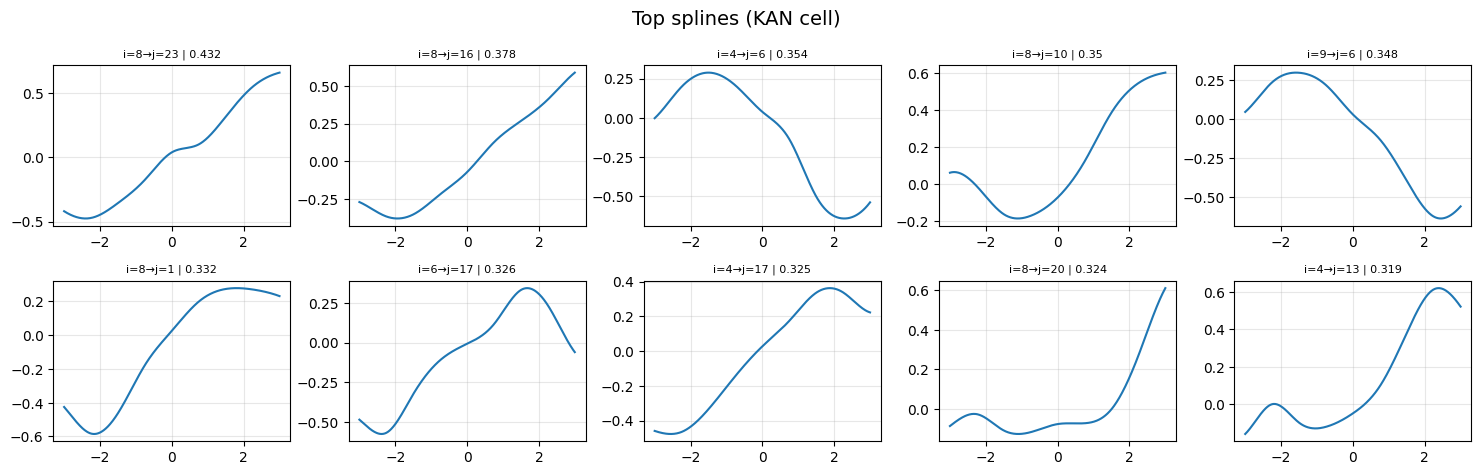

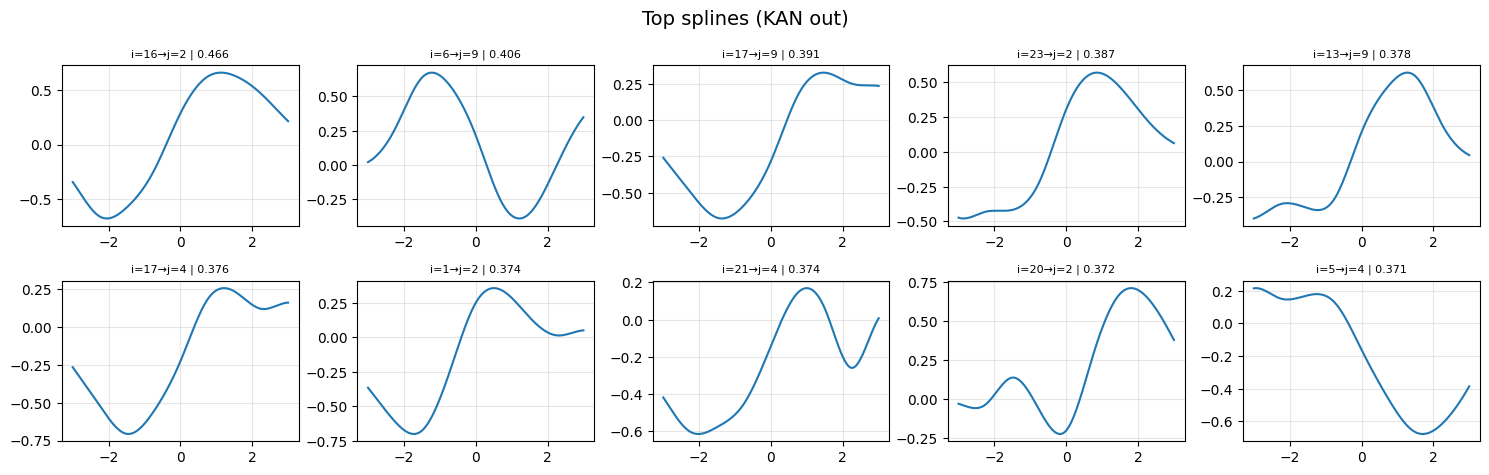

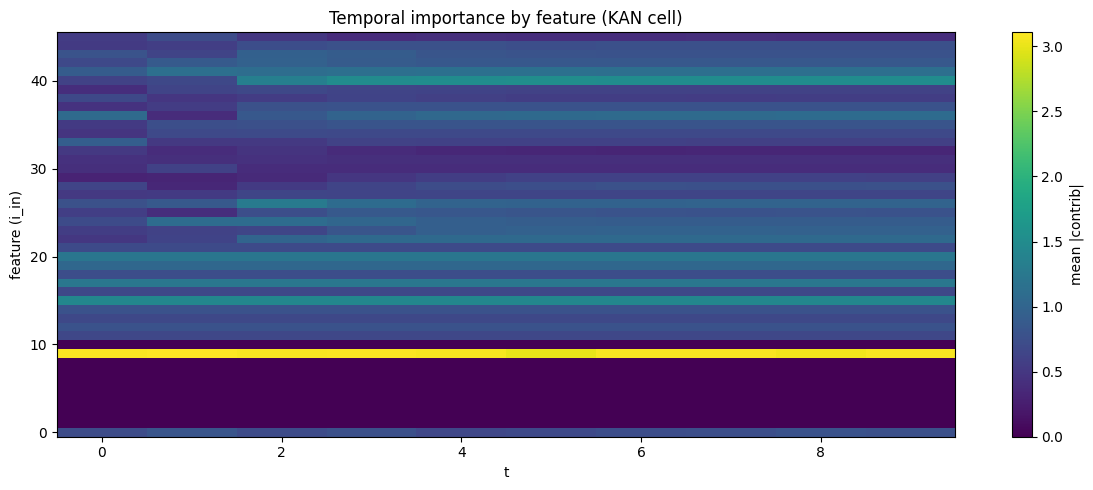

In [62]:
# --- USO: top edges + tabela + plots + heatmap ---
layer_cell = model.seqKAN.kan_cell.act_fun[0]
layer_out = model.seqKAN.kan_out.act_fun[0]

top_cell = extract_top_edges(layer_cell, topn=20, score="coef_l2")
top_out  = extract_top_edges(layer_out,  topn=20, score="coef_l2")

df_cell = pd.DataFrame(top_cell)
df_out  = pd.DataFrame(top_out)
df_cell.to_csv('top_edges_cell.csv', index=False)
df_out.to_csv('top_edges_out.csv', index=False)

display(df_cell.head(20))
display(df_out.head(20))

plot_edges_splines(layer_cell, top_cell, title='Top splines (KAN cell)', nrows=2, ncols=5)
plot_edges_splines(layer_out,  top_out,  title='Top splines (KAN out)',  nrows=2, ncols=5)

# heatmap temporal (usa contribs_cell; calcula se nao existir)
if 'edge_contribs' not in globals():
    from seqkan.kan.spline import coef2curve
    import torch
    @torch.no_grad()
    def edge_contribs(seqkan, x, mask=None, which="cell"):
        B, T, C = x.shape
        device = x.device
        h = torch.zeros(B, seqkan.hidden_size, device=device)
        if x.shape[-1] == seqkan.input_size:
            x_in = x
        else:
            if mask is None:
                mask = torch.ones_like(x)
            x_in = torch.cat([x, mask], dim=-1)
        contribs = []
        for t in range(T):
            h_in = torch.cat([x_in[:, t, :], h], dim=-1)
            layer = seqkan.kan_cell.act_fun[0]
            y_cell = coef2curve(h_in, layer.grid, layer.coef, layer.k)
            y_cell = y_cell * layer.mask[None, :, :]
            h = seqkan.kan_cell(h_in)
            if which == "cell":
                contribs.append(y_cell)
            elif which == "out":
                layer_out = seqkan.kan_out.act_fun[0]
                y_out = coef2curve(h, layer_out.grid, layer_out.coef, layer_out.k)
                y_out = y_out * layer_out.mask[None, :, :]
                contribs.append(y_out)
            else:
                raise ValueError("which must be cell or out")
        return torch.stack(contribs, dim=1)

if 'contribs_cell' not in globals():
    contribs_cell = edge_contribs(model.seqKAN, x_batch, mask=globals().get('mask_batch'), which="cell")
temporal_feature_heatmap(contribs_cell, title='Temporal importance by feature (KAN cell)')


In [63]:
# --- Helper: map indices to feature names ---
# Tenta obter feature_cols do notebook ou do dl.df
if 'feature_cols' in globals():
    _feature_cols = feature_cols
elif 'dl' in globals():
    df = dl.df.copy()
    _feature_cols = [c for c in df.columns if c not in ('states', 'anomaly') and not str(c).startswith('state-')]
else:
    _feature_cols = None

if _feature_cols is None:
    raise ValueError('Nao consegui inferir feature_cols. Defina feature_cols manualmente.')

# indice -> nome
feat_map = {i: name for i, name in enumerate(_feature_cols)}
print('n_features:', len(_feature_cols))
print('exemplo map:', list(feat_map.items())[:5])


n_features: 11
exemplo map: [(0, 'PH (CBM) 1st Stage ExpPress Ratio'), (1, 'PH (CBM) 1st Stage Poly Head Dev'), (2, 'PH (CBM) 1st Stage ActShaft Power'), (3, 'PH (CBM) 1st Stage Press Rat Dev'), (4, 'PH (CBM) 1st Stg ActCompr Poly Head')]


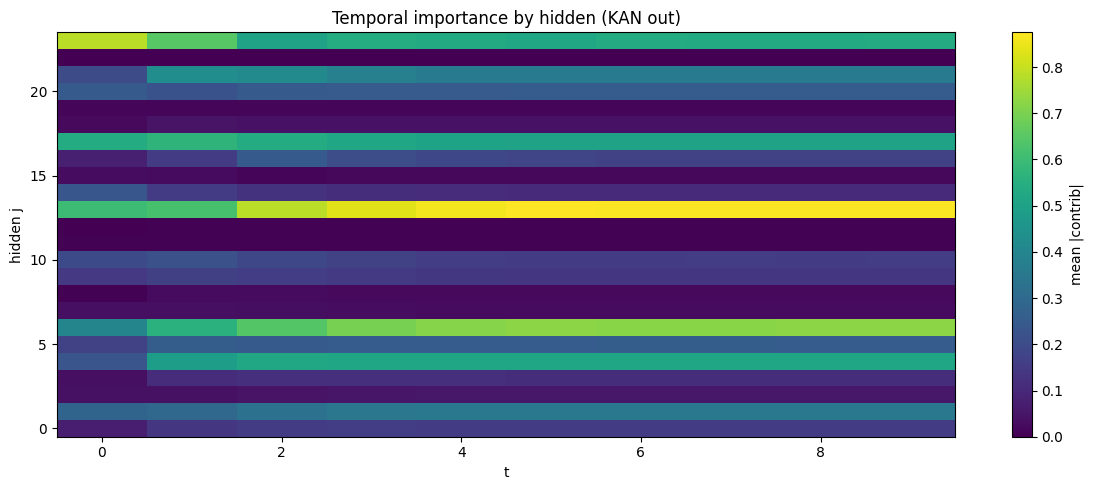

In [64]:
# --- Heatmap temporal KAN out (por hidden ao longo do tempo) ---
def temporal_hidden_heatmap(contribs_out, title='Temporal importance by hidden (KAN out)'):
    # contribs_out: (B,T,hidden,out_dim)
    bt = contribs_out.abs().mean(dim=0)  # (T,hidden,out_dim)
    hid_imp = bt.sum(dim=2)            # (T,hidden)
    data = hid_imp.T.cpu().numpy()     # (hidden, T)
    plt.figure(figsize=(12, 5))
    plt.imshow(data, aspect='auto', origin='lower', interpolation='nearest')
    plt.colorbar(label='mean |contrib|')
    plt.xlabel('t')
    plt.ylabel('hidden j')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# uso (garante contribs_out calculado)
if 'contribs_out' not in globals():
    contribs_out = edge_contribs(model.seqKAN, x_batch, mask=globals().get('mask_batch'), which="out")
temporal_hidden_heatmap(contribs_out, title='Temporal importance by hidden (KAN out)')


In [ ]:
# --- Feature 7 diagnostics: ranking, splines, clamp histogram ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

FEATURE_IDX = 7  # ajuste se necessario

# 1) ranking completo por i_in (KAN cell)
layer_cell = model.seqKAN.kan_cell.act_fun[0]
scores = _edge_scores_from_layer(layer_cell, score="coef_l2")
if scores.shape[0] == layer_cell.grid.shape[0]:
    s = scores
else:
    s = scores.T
# soma por i_in
score_by_i = s.abs().sum(dim=1).detach().cpu().numpy()
rank_df = pd.DataFrame({"i_in": np.arange(len(score_by_i)), "score_sum": score_by_i})
rank_df = rank_df.sort_values("score_sum", ascending=False).reset_index(drop=True)
display(rank_df.head(20))
print('feature 7 rank:', int(rank_df.index[rank_df['i_in'] == FEATURE_IDX][0]) + 1)

# 2) top splines ligadas à feature 7
j_scores = s[FEATURE_IDX].detach().cpu().numpy()
top_js = np.argsort(-np.abs(j_scores))[:10]
print('Top j for feature 7:', top_js)

fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=False, sharey=False)
axes = axes.flatten()
for ax, j in zip(axes, top_js):
    x, y = sample_spline(layer_cell, FEATURE_IDX, int(j), n=400)
    ax.plot(x, y)
    ax.set_title(f"7→{int(j)} | {j_scores[j]:.3g}", fontsize=8)
    ax.grid(True, alpha=0.3)
for ax in axes[len(top_js):]:
    ax.axis('off')
fig.suptitle('Top splines ligadas à feature 7', fontsize=14)
fig.tight_layout()
plt.show()

# 3) histograma antes/depois do clamp (se x_min/x_max definidos)
if 'dl' in globals():
    df = dl.df.copy()
    if 'feature_cols' in globals():
        fcols = feature_cols
    else:
        fcols = [c for c in df.columns if c not in ('states','anomaly') and not str(c).startswith('state-')]
    if FEATURE_IDX < len(fcols):
        col = fcols[FEATURE_IDX]
        raw = df[col].values.astype(float)
        x_min = getattr(model, 'x_min', None)
        x_max = getattr(model, 'x_max', None)
        if x_min is not None and x_max is not None:
            clamped = np.clip(raw, x_min, x_max)
            plt.figure(figsize=(8,4))
            plt.hist(raw, bins=50, alpha=0.4, label='raw')
            plt.hist(clamped, bins=50, alpha=0.4, label='clamped')
            plt.axvline(x_min, color='red', linestyle='--')
            plt.axvline(x_max, color='red', linestyle='--')
            plt.title(f'Feature {FEATURE_IDX} ({col}) raw vs clamped')
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print('x_min/x_max nao definidos no model')
    else:
        print('FEATURE_IDX fora do range de feature_cols')


x_min/x_max: -3.0 3.0
MSE mean (clamp >= median 1.000): 14284256.000000
MSE mean (clamp <  median 1.000): nan


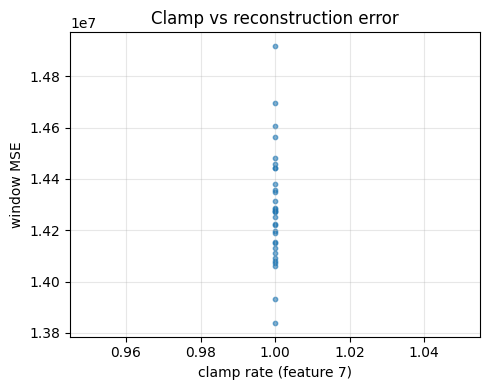

In [54]:
# --- Clamp vs reconstruction error analysis ---
import numpy as np
import torch

FEATURE_IDX = 7  # ajuste se necessario

# x_min/x_max usados no treino (se nao estiverem no model, usa run_config)
x_min = getattr(model, 'x_min', None)
x_max = getattr(model, 'x_max', None)
if x_min is None or x_max is None:
    if 'run_config_tsdf_seqkanseq' in globals():
        x_min = run_config_tsdf_seqkanseq['train_params'].get('x_min')
        x_max = run_config_tsdf_seqkanseq['train_params'].get('x_max')

print('x_min/x_max:', x_min, x_max)

# calcula clamp por janela
# x_batch: (B,T,C)
vals = x_batch[:, :, FEATURE_IDX]
if x_min is not None and x_max is not None:
    clamped = (vals <= x_min) | (vals >= x_max)
    clamp_rate = clamped.float().mean(dim=1)  # (B,)
else:
    raise ValueError('x_min/x_max indefinidos — nao consigo avaliar clamp')

# reconstrução para medir erro
model.eval()
with torch.no_grad():
    # monta mascara se existir
    if 'mask_batch' in globals() and mask_batch is not None:
        m = mask_batch
    else:
        m = torch.ones_like(x_batch)
    x_masked = x_batch * m
    out = model.forward(x_masked, return_x_hat=True, mask=m, test=True)
    # TSDF_seqKANSeq retorna x_hat na posicao 3
    x_hat = out[3]
    # erro por janela (MSE)
    mse = ((x_hat - x_batch) ** 2).mean(dim=(1,2))

# compara erro com clamp
# separar janelas com clamp alto vs baixo
thr = clamp_rate.median().item()
hi = mse[clamp_rate >= thr].mean().item()
lo = mse[clamp_rate < thr].mean().item()
print(f'MSE mean (clamp >= median {thr:.3f}): {hi:.6f}')
print(f'MSE mean (clamp <  median {thr:.3f}): {lo:.6f}')

# scatter clamp_rate vs mse
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))
plt.scatter(clamp_rate.cpu().numpy(), mse.cpu().numpy(), s=10, alpha=0.6)
plt.xlabel('clamp rate (feature 7)')
plt.ylabel('window MSE')
plt.title('Clamp vs reconstruction error')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


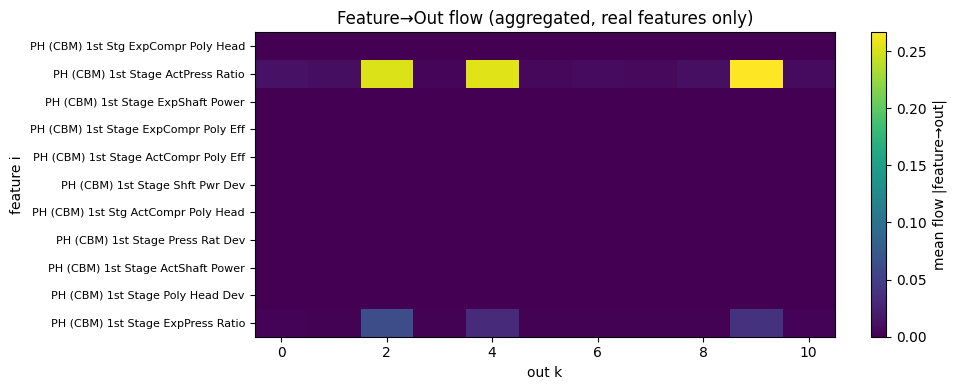

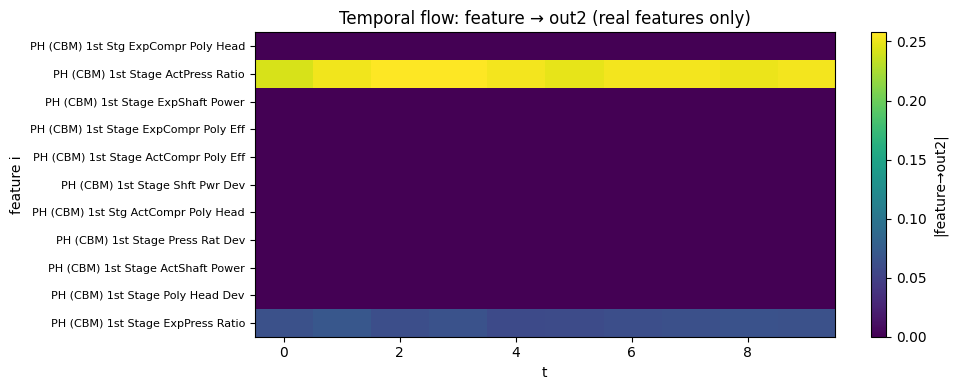

Top hidden mediators: [13, 6, 4, 23, 17] [1.590940237045288, 1.4494476318359375, 1.1136102676391602, 0.8373767137527466, 0.8315720558166504]


In [60]:
# --- Feature→Out flow (connect KAN cell + KAN out) ---
import numpy as np
import torch
import matplotlib.pyplot as plt

# garante contribs_cell e contribs_out
if 'contribs_cell' not in globals():
    contribs_cell = edge_contribs(model.seqKAN, x_batch, mask=globals().get('mask_batch'), which='cell')
if 'contribs_out' not in globals():
    contribs_out = edge_contribs(model.seqKAN, x_batch, mask=globals().get('mask_batch'), which='out')

A = contribs_cell.abs().mean(dim=0)  # (T,in_dim,hidden)
B = contribs_out.abs().mean(dim=0)   # (T,hidden,out_dim)

# flow_t: (T,in_dim,out_dim)
flow_t = torch.einsum('tih,tho->tio', A, B)
flow = flow_t.mean(dim=0)  # (in_dim,out_dim)

# --- keep only real features (exclude mask inputs) ---
if 'feat_map' in globals():
    n_feat = len(feat_map)
else:
    n_feat = flow.shape[0]//2  # fallback
flow_feat = flow[:n_feat, :]

# --- heatmap feature→out (agregado) com rótulos ---
plt.figure(figsize=(10,4))
plt.imshow(flow_feat.cpu().numpy(), aspect='auto', origin='lower')
plt.colorbar(label='mean flow |feature→out|')
plt.xlabel('out k')
plt.ylabel('feature i')
plt.title('Feature→Out flow (aggregated, real features only)')
if 'feat_map' in globals():
    plt.yticks(np.arange(n_feat), [feat_map[i] for i in range(n_feat)], fontsize=8)
plt.tight_layout()
plt.show()

# --- heatmap temporal para uma saída específica ---
k = 2  # escolha a saída
plt.figure(figsize=(10,4))
plt.imshow(flow_t[:, :n_feat, k].T.cpu().numpy(), aspect='auto', origin='lower')
plt.colorbar(label=f'|feature→out{k}|')
plt.xlabel('t')
plt.ylabel('feature i')
plt.title(f'Temporal flow: feature → out{k} (real features only)')
if 'feat_map' in globals():
    plt.yticks(np.arange(n_feat), [feat_map[i] for i in range(n_feat)], fontsize=8)
plt.tight_layout()
plt.show()

# --- top hidden mediadores ---
hidden_score = (A.sum(dim=1) * B.sum(dim=2)).mean(dim=0)  # (hidden,)
top_hidden = torch.topk(hidden_score, k=5)
print('Top hidden mediators:', top_hidden.indices.tolist(), top_hidden.values.tolist())


In [ ]:
# --- Export spline formulas (grid + coef) for top edges ---
import json
import numpy as np

def spline_formula_dict(layer, edges, max_edges=20):
    out = []
    k = int(layer.k)
    for e in edges[:max_edges]:
        i = int(e['i_in']) if isinstance(e, dict) else int(e[0])
        j = int(e['j_out']) if isinstance(e, dict) else int(e[1])
        grid = layer.grid[i].detach().cpu().numpy().tolist()
        coef = layer.coef[i, j].detach().cpu().numpy().tolist()
        mask = float(layer.mask[i, j].detach().cpu().item()) if hasattr(layer, 'mask') else None
        out.append({
            'i_in': i,
            'j_out': j,
            'k': k,
            'grid': grid,
            'coef': coef,
            'mask': mask,
        })
    return out

# exige top_cell/top_out já calculados
layer_cell = model.seqKAN.kan_cell.act_fun[0]
layer_out = model.seqKAN.kan_out.act_fun[0]

cell_formulas = spline_formula_dict(layer_cell, top_cell, max_edges=20)
out_formulas  = spline_formula_dict(layer_out,  top_out,  max_edges=20)

with open('top20_splines_cell.json', 'w') as f:
    json.dump(cell_formulas, f, indent=2)
with open('top20_splines_out.json', 'w') as f:
    json.dump(out_formulas, f, indent=2)

print('saved: top20_splines_cell.json, top20_splines_out.json')


In [ ]:
# --- Top-5 spline expressions (KAN cell + KAN out) ---
import json

def spline_expr_string(i_in, j_out, k, grid, coef, name='phi'):
    return (
        f"{name}_{{{i_in}->{j_out}}}(x) = sum_m c_m * B_m(x; grid, k)\n"
        + f"  k={k}\n"
        + f"  grid={grid}\n"
        + f"  coef={coef}"
    )

def top5_exprs(layer, edges, name='phi', max_edges=5):
    out = []
    k = int(layer.k)
    for e in edges[:max_edges]:
        i = int(e['i_in']) if isinstance(e, dict) else int(e[0])
        j = int(e['j_out']) if isinstance(e, dict) else int(e[1])
        grid = [float(x) for x in layer.grid[i].detach().cpu().tolist()]
        coef = [float(x) for x in layer.coef[i, j].detach().cpu().tolist()]
        expr = spline_expr_string(i, j, k, grid, coef, name=name)
        out.append(expr)
    return out

# exige top_cell/top_out
layer_cell = model.seqKAN.kan_cell.act_fun[0]
layer_out = model.seqKAN.kan_out.act_fun[0]

top5_cell_exprs = top5_exprs(layer_cell, top_cell, name='phi', max_edges=5)
top5_out_exprs  = top5_exprs(layer_out,  top_out,  name='psi', max_edges=5)

print('Top 5 KAN cell splines:')
for s in top5_cell_exprs:
    print(s)
    print('-'*60)

print('Top 5 KAN out splines:')
for s in top5_out_exprs:
    print(s)
    print('-'*60)


In [ ]:
# --- Memory vs New decomposition (KAN cell) and flow to output ---
import torch
import numpy as np
import matplotlib.pyplot as plt
from seqkan.kan.spline import coef2curve

@torch.no_grad()
def mem_new_contribs(seqkan, x, mask=None):
    # x: (B,T,C) features
    B, T, C = x.shape
    device = x.device
    h = torch.zeros(B, seqkan.hidden_size, device=device)
    layer = seqkan.kan_cell.act_fun[0]
    in_dim = layer.grid.shape[0]
    n_feat = C
    if mask is None:
        mask = torch.ones_like(x)
    # assume input to cell is [x, mask] (state_dim = 2*C)
    x_in = torch.cat([x, mask], dim=-1)
    mem_list = []
    new_list = []
    out_contribs = []

    for t in range(T):
        h_in = torch.cat([x_in[:, t, :], h], dim=-1)  # (B, 2C + H)
        y = coef2curve(h_in, layer.grid, layer.coef, layer.k)  # (B, in_dim, hidden)
        y = y * layer.mask[None, :, :]

        # split contributions: new (x+mask) vs memory (h_prev)
        new_y = y[:, :2*n_feat, :]
        mem_y = y[:, 2*n_feat:, :]

        mem_list.append(mem_y)
        new_list.append(new_y)

        # update hidden
        h = seqkan.kan_cell(h_in)

        # out contributions
        layer_out = seqkan.kan_out.act_fun[0]
        y_out = coef2curve(h, layer_out.grid, layer_out.coef, layer_out.k)
        y_out = y_out * layer_out.mask[None, :, :]
        out_contribs.append(y_out)

    mem = torch.stack(mem_list, dim=1)   # (B,T,H_mem,hidden) but H_mem = hidden prev inputs count
    new = torch.stack(new_list, dim=1)   # (B,T,2C,hidden)
    out = torch.stack(out_contribs, dim=1)  # (B,T,hidden,out)
    return mem, new, out

# --- compute ---
mem_contribs, new_contribs, out_contribs = mem_new_contribs(model.seqKAN, x_batch, mask=globals().get('mask_batch'))

# ratios over time
mem_mag = mem_contribs.abs().mean(dim=(0,2,3))  # (T,)
new_mag = new_contribs.abs().mean(dim=(0,2,3))  # (T,)
total = mem_mag + new_mag + 1e-12
mem_ratio = mem_mag / total
new_ratio = new_mag / total

plt.figure(figsize=(8,4))
plt.plot(mem_ratio.cpu().numpy(), label='memory')
plt.plot(new_ratio.cpu().numpy(), label='new input')
plt.title('Memory vs New contribution (KAN cell)')
plt.xlabel('t')
plt.ylabel('ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- flow to output: memory vs new ---
A_mem = mem_contribs.abs().mean(dim=0)  # (T, H_mem, hidden)
A_new = new_contribs.abs().mean(dim=0)  # (T, 2C, hidden)
B = out_contribs.abs().mean(dim=0)      # (T, hidden, out)

flow_mem_t = torch.einsum('tih,tho->tio', A_mem, B)
flow_new_t = torch.einsum('tih,tho->tio', A_new, B)

# aggregate
flow_mem = flow_mem_t.mean(dim=0)
flow_new = flow_new_t.mean(dim=0)

plt.figure(figsize=(10,4))
plt.imshow(flow_new.cpu().numpy(), aspect='auto', origin='lower')
plt.colorbar(label='new flow |feature→out|')
plt.title('Flow from NEW input to output')
plt.xlabel('out k')
plt.ylabel('new input index (x+mask)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.imshow(flow_mem.cpu().numpy(), aspect='auto', origin='lower')
plt.colorbar(label='memory flow |h_prev→out|')
plt.title('Flow from MEMORY to output')
plt.xlabel('out k')
plt.ylabel('memory index (h_prev)')
plt.tight_layout()
plt.show()


In [ ]:
# --- Plot NEW input flow with feature vs mask separation ---
import numpy as np
import matplotlib.pyplot as plt

# assume flow_new computed in memory-vs-new cell
if 'flow_new' not in globals():
    raise ValueError('flow_new not found. Run the memory vs new cell first.')

# infer number of real features
if 'feat_map' in globals():
    n_feat = len(feat_map)
else:
    n_feat = flow_new.shape[0] // 2

plt.figure(figsize=(10,4))
plt.imshow(flow_new.cpu().numpy(), aspect='auto', origin='lower')
plt.colorbar(label='new flow |feature→out|')
plt.xlabel('out k')
plt.ylabel('new input index (x+mask)')
plt.title('Flow from NEW input to output (features + masks)')
# horizontal line separating features and masks
plt.axhline(n_feat - 0.5, color='white', linestyle='--', linewidth=1)
plt.text(0.1, n_feat - 0.2, 'features', color='white', fontsize=9)
plt.text(0.1, n_feat + 0.5, 'masks', color='white', fontsize=9)
plt.tight_layout()
plt.show()


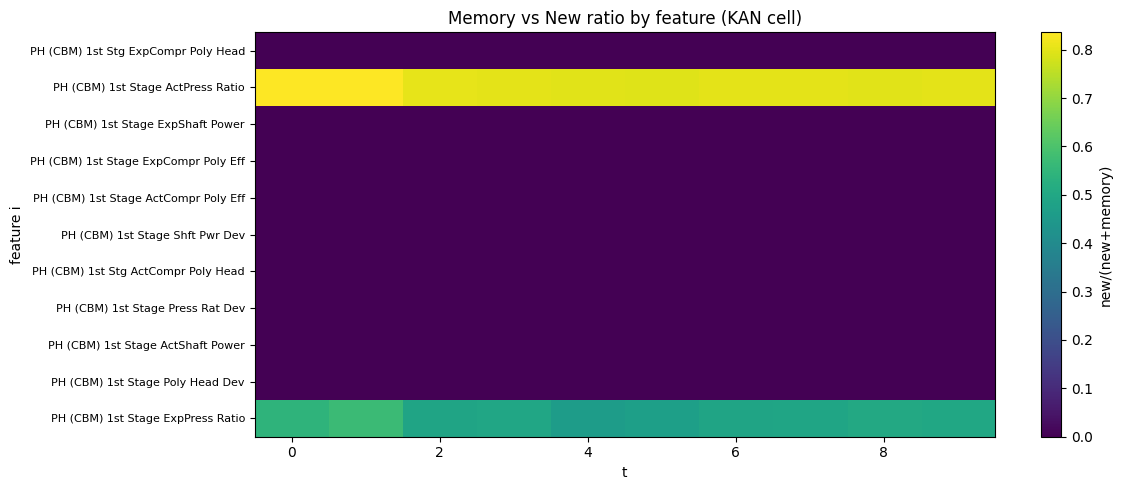

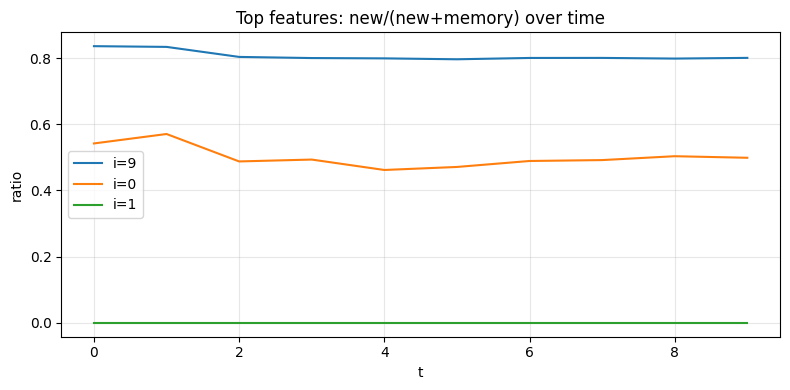

In [73]:
# --- Memory vs New by feature (keep global plot unchanged) ---
import numpy as np
import matplotlib.pyplot as plt

# requires mem_contribs and new_contribs from previous cell
if 'mem_contribs' not in globals() or 'new_contribs' not in globals():
    raise ValueError('Run the memory vs new decomposition cell first.')

# new_contribs: (B,T,2C,hidden) -> split x vs mask
B, T, twoC, H = new_contribs.shape
C = twoC // 2
new_x = new_contribs[:, :, :C, :]
# aggregate magnitudes
new_x_mag = new_x.abs().mean(dim=(0,3))   # (T, C)
mem_mag = mem_contribs.abs().mean(dim=(0,2,3))  # (T,)

# ratio per feature: new_x_i / (new_x_i + mem_total)
mem_mag_exp = mem_mag[:, None]  # (T,1)
ratio = new_x_mag / (new_x_mag + mem_mag_exp + 1e-12)  # (T,C)

# heatmap: feature x time
plt.figure(figsize=(12, 5))
plt.imshow(ratio.T, aspect='auto', origin='lower', interpolation='nearest')
plt.colorbar(label='new/(new+memory)')
plt.xlabel('t')
plt.ylabel('feature i')
plt.title('Memory vs New ratio by feature (KAN cell)')
if 'feat_map' in globals():
    plt.yticks(np.arange(C), [feat_map[i] for i in range(C)], fontsize=8)
plt.tight_layout()
plt.show()

# optional: plot curves for top-3 features with highest mean ratio
mean_ratio = ratio.mean(dim=0).cpu().numpy()
top_idx = np.argsort(-mean_ratio)[:3]
plt.figure(figsize=(8,4))
for i in top_idx:
    plt.plot(ratio[:, i].cpu().numpy(), label=f'i={i}')
plt.title('Top features: new/(new+memory) over time')
plt.xlabel('t')
plt.ylabel('ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


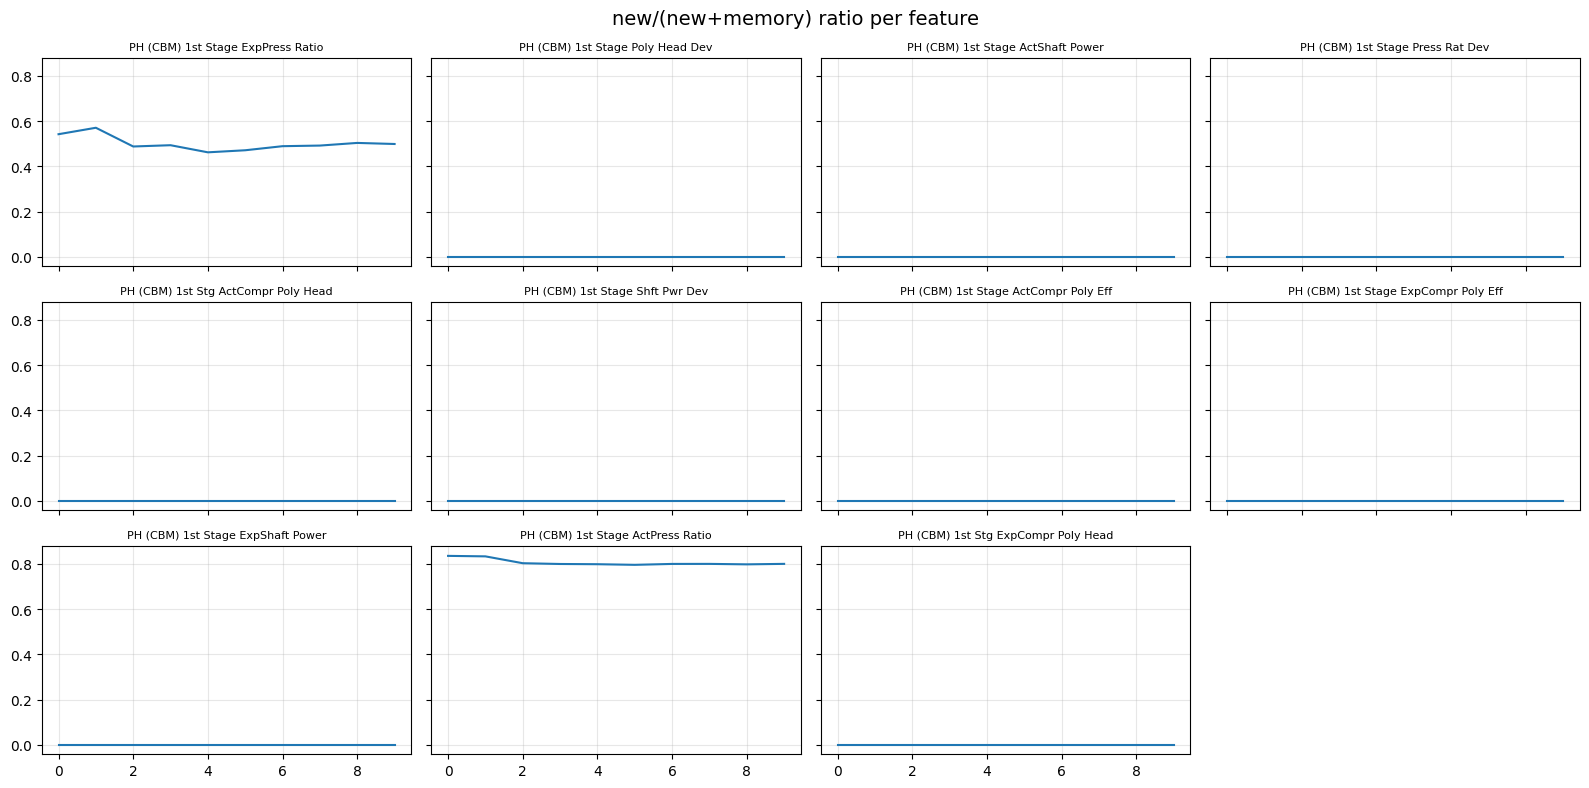

In [74]:
# --- Plot new/(new+memory) curves for all 11 features ---
import numpy as np
import matplotlib.pyplot as plt

# requires ratio from previous per-feature cell
if 'ratio' not in globals():
    raise ValueError('Run the per-feature memory vs new cell first (ratio not found).')

C = ratio.shape[1]
nrows, ncols = 3, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()
for i in range(C):
    ax = axes[i]
    ax.plot(ratio[:, i].cpu().numpy())
    if 'feat_map' in globals():
        title = feat_map[i]
    else:
        title = f'feature {i}'
    ax.set_title(title, fontsize=8)
    ax.grid(True, alpha=0.3)
for ax in axes[C:]:
    ax.axis('off')
fig.suptitle('new/(new+memory) ratio per feature', fontsize=14)
fig.tight_layout()
plt.show()
